In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df.shape

(7043, 21)

In [15]:
pd.set_option('display.max_columns', 21)

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
#checking to see if there are any duplicates
df.loc[df.duplicated(subset=['customerID'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [17]:
#checking to see if there is any inproper datatypes
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [20]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors='coerce')

In [24]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [23]:
df['TotalCharges']= df['TotalCharges'].fillna(0)

In [51]:
#anaylsing the relationship between contract types and churn
contract_analyses = df.groupby('Contract')['Churn'].value_counts(normalize=True).mul(100).reset_index()
contract_analyses.columns = ['Contract', 'Churn', 'Percentage']
print(contract_analyses)

         Contract Churn  Percentage
0  Month-to-month    No   57.290323
1  Month-to-month   Yes   42.709677
2        One year    No   88.730482
3        One year   Yes   11.269518
4        Two year    No   97.168142
5        Two year   Yes    2.831858


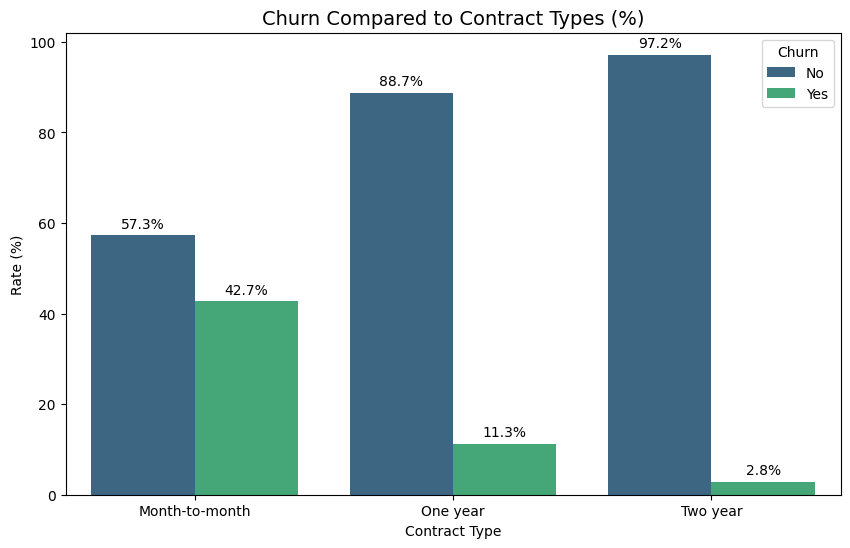

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Contract', y='Percentage', hue='Churn', data=contract_analyses, palette='viridis')


plt.title('Churn Compared to Contract Types (%)', fontsize=14)
plt.ylabel('Rate (%)')
plt.xlabel('Contract Type')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%', padding=3)

plt.show()

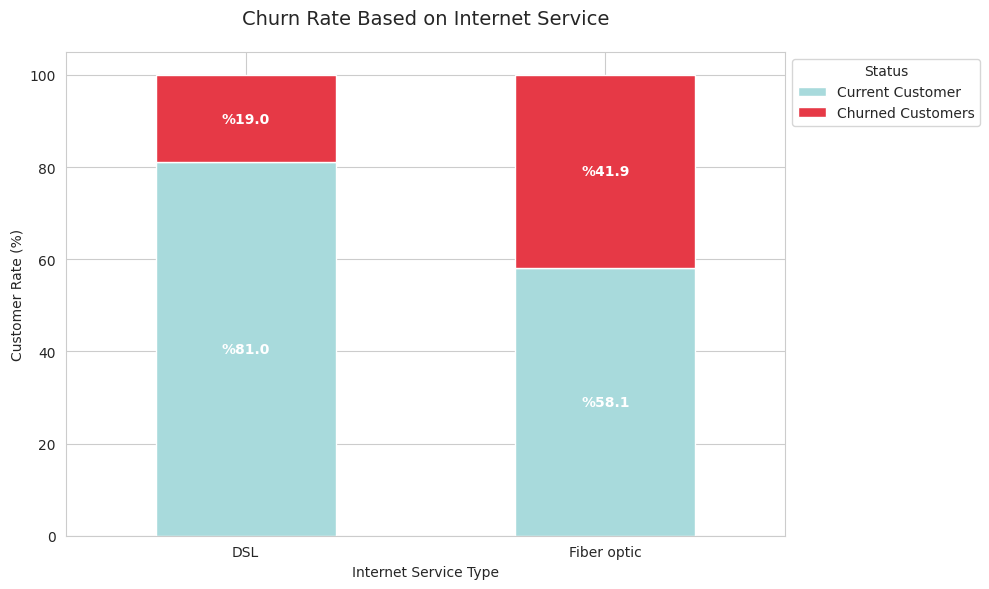

In [73]:

#checking the relaitonship between internet service and churn rates
df_internet = df[df['InternetService'] != 'No']
internet_churn_ratio = df_internet.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100

ax = internet_churn_ratio.plot(kind='bar', stacked=True, figsize=(10,6), color=['#A8DADC', '#E63946'])

plt.title('Churn Rate Based on Internet Service', fontsize=14, pad=20)
plt.ylabel('Customer Rate (%)')
plt.xlabel('Internet Service Type')
plt.xticks(rotation=0)
plt.legend(title='Status', labels=['Current Customer', 'Churned Customers'], bbox_to_anchor=(1, 1))

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        ax.annotate(f'%{height:.1f}', (p.get_x() + width/2, p.get_y() + height/2),
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

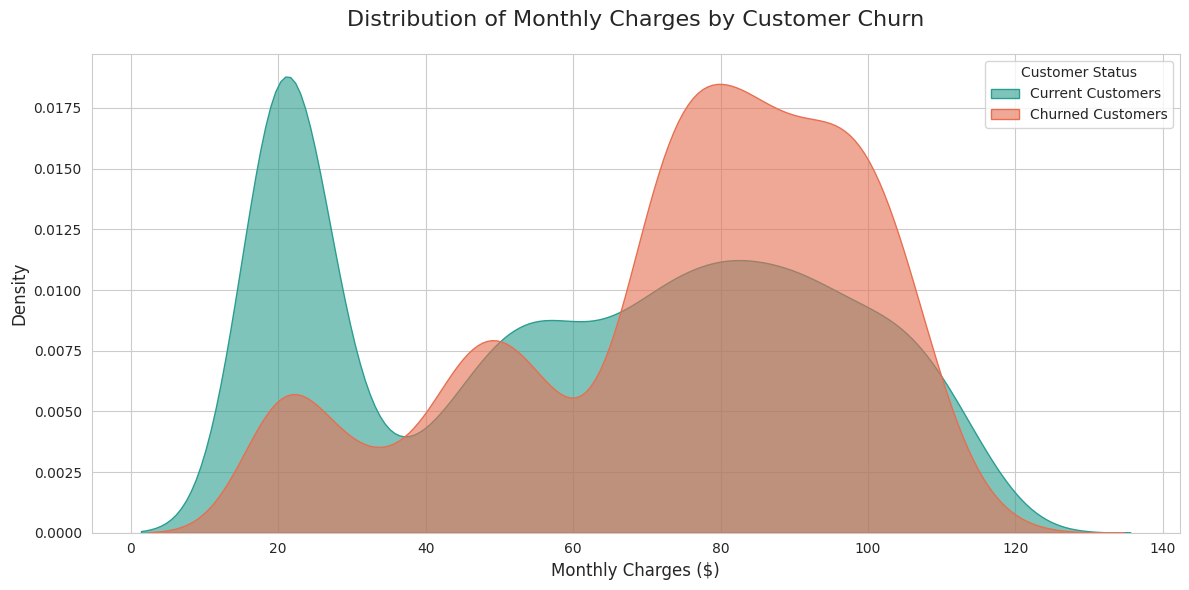

In [70]:

plt.figure(figsize=(12, 6))

sns.kdeplot(data=df[df['Churn'] == 'No'], x='MonthlyCharges',
            fill=True, label='Current Customers', color='#2A9D8F', alpha=0.6)
sns.kdeplot(data=df[df['Churn'] == 'Yes'], x='MonthlyCharges',
            fill=True, label='Churned Customers', color='#E76F51', alpha=0.6)

plt.title('Distribution of Monthly Charges by Customer Churn', fontsize=16, pad=20)
plt.xlabel('Monthly Charges ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Customer Status', loc='upper right')

plt.tight_layout()
plt.show()


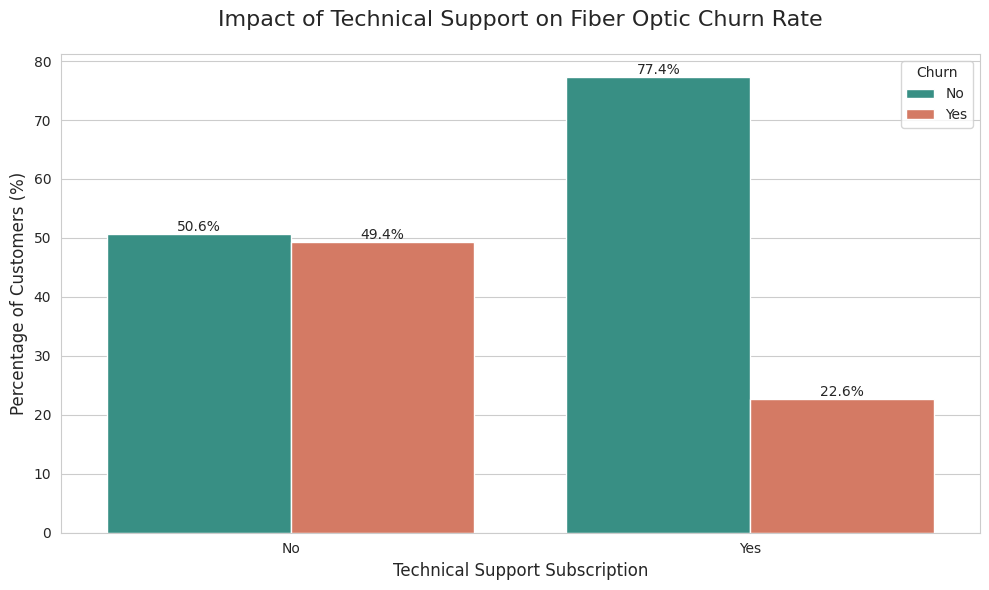

In [82]:
#investigating the reason why fiber optic users may be leaving
fiber_users = df[df['InternetService']== 'Fiber optic']
tech_analysis= fiber_users.groupby('TechSupport')['Churn'].value_counts(normalize=True).rename('Ratio').mul(100).reset_index()
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
custom_palette = {'No': '#2A9D8F', 'Yes': '#E76F51'}
ax = sns.barplot(data=tech_analysis, x='TechSupport', y='Ratio', hue='Churn', palette=custom_palette)
for container in ax.containers:
  ax.bar_label(container, fmt= '%.1f%%')
plt.title('Impact of Technical Support on Fiber Optic Churn Rate', fontsize=16, pad=20)
plt.xlabel('Technical Support Subscription', fontsize=12)
plt.ylabel('Percentage of Customers (%)', fontsize=12)
plt.tight_layout()
plt.show()